In [54]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier

from targetree import CART
from targetree.tree_vis import plot_cart_tree
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "examples":
    PROJECT_ROOT = PROJECT_ROOT.parent
EXAMPLES_DIR = PROJECT_ROOT / "examples"
DATA_DIR = EXAMPLES_DIR / "data"

### 1. diabetes

In [55]:
df_diabetes = pd.read_csv(DATA_DIR / "diabetes.csv")

In [56]:
y1 = np.array(df_diabetes['Outcome'])
X1 = np.array(df_diabetes.drop(['Outcome'],axis=1))

In [57]:
df_diabetes

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [58]:
cut = 0.6
max_depth = 3

[Glucose <= 127.5000]
  [Age <= 28.5000]
    [BMI <= 30.9500]
      Leaf: mean=0.013, n=151
      Leaf: mean=0.175, n=120
    [BMI <= 26.3500]
      Leaf: mean=0.049, n=41
      Leaf: mean=0.399, n=173
  [BMI <= 29.9500]
    [Glucose <= 145.5000]
      Leaf: mean=0.146, n=41
      Leaf: mean=0.514, n=35
    [Glucose <= 157.5000]
      Leaf: mean=0.609, n=115
      Leaf: mean=0.870, n=92


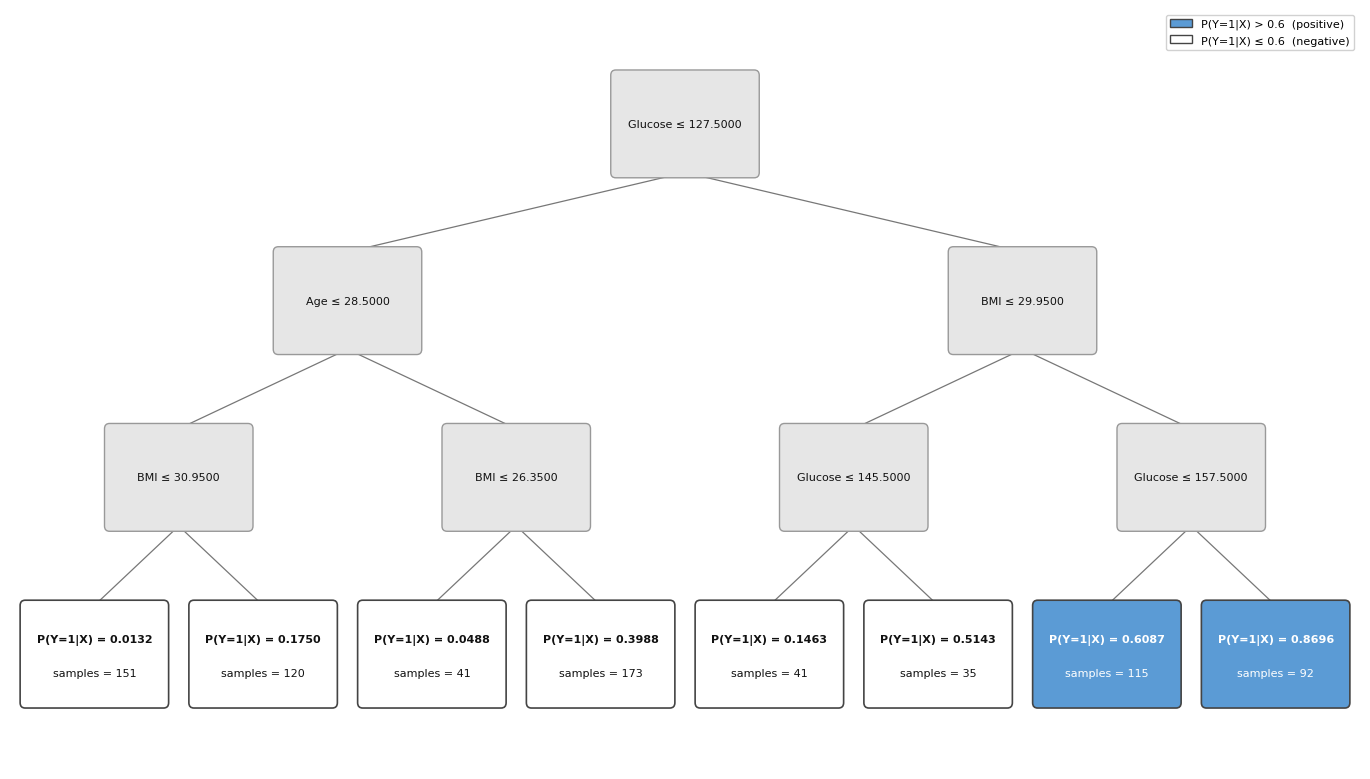

In [59]:
###### cart ######
model = CART(depth=max_depth, minimum_portion=0.02, lbd=0, cut=cut, method = 'cart',feature_name = np.array(df_diabetes.columns))
model.fit(X1, y1)
model.print_tree()
plot_cart_tree(model.tree, feature_name=model.feature_name, cut=model.cut)

[Glucose <= 127.5000]
  [Age <= 28.5000]
    [BMI <= 22.2500]
      Leaf: mean=0.000, n=35
      Leaf: mean=0.097, n=236
    [BMI <= 28.2500]
      Leaf: mean=0.222, n=63
      Leaf: mean=0.377, n=151
  [BMI <= 29.9500]
    [Glucose <= 166.5000]
      Leaf: mean=0.250, n=64
      Leaf: mean=0.667, n=12
    [Glucose <= 129.5000]
      Leaf: mean=0.579, n=19
      Leaf: mean=0.739, n=188


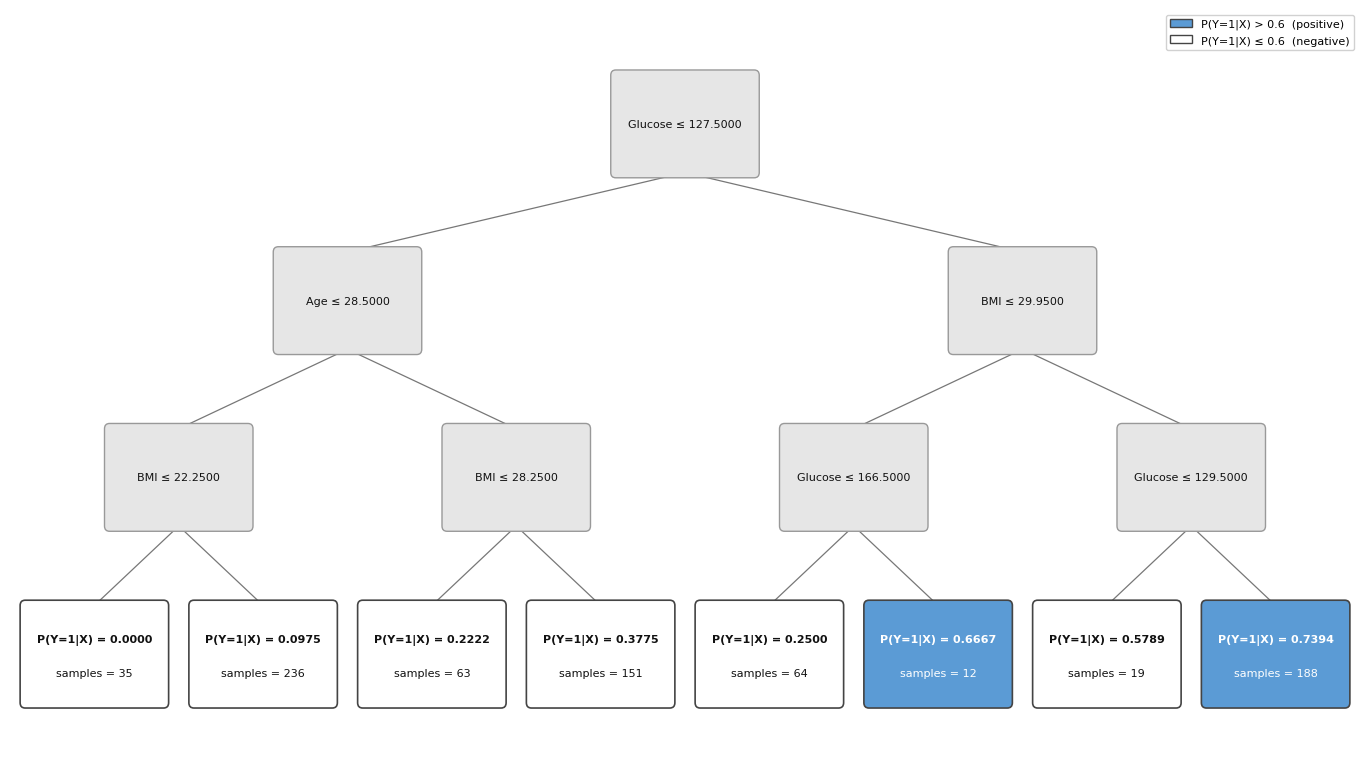

In [60]:
# mdfs
model = CART(depth=max_depth, minimum_portion=0.02, lbd=1, cut=cut, method = 'mdfs',feature_name = np.array(df_diabetes.columns))
model.fit(X1, y1)
model.print_tree()
plot_cart_tree(model.tree, feature_name=model.feature_name, cut=model.cut)

[Glucose <= 127.5000]
  [Age <= 28.5000]
    [BMI <= 30.9500]
      Leaf: mean=0.013, n=151
      Leaf: mean=0.175, n=120
    [BMI <= 26.3500]
      Leaf: mean=0.049, n=41
      Leaf: mean=0.399, n=173
  [BMI <= 29.9500]
    [Glucose <= 166.5000]
      Leaf: mean=0.250, n=64
      Leaf: mean=0.667, n=12
    [Glucose <= 157.5000]
      Leaf: mean=0.609, n=115
      Leaf: mean=0.870, n=92


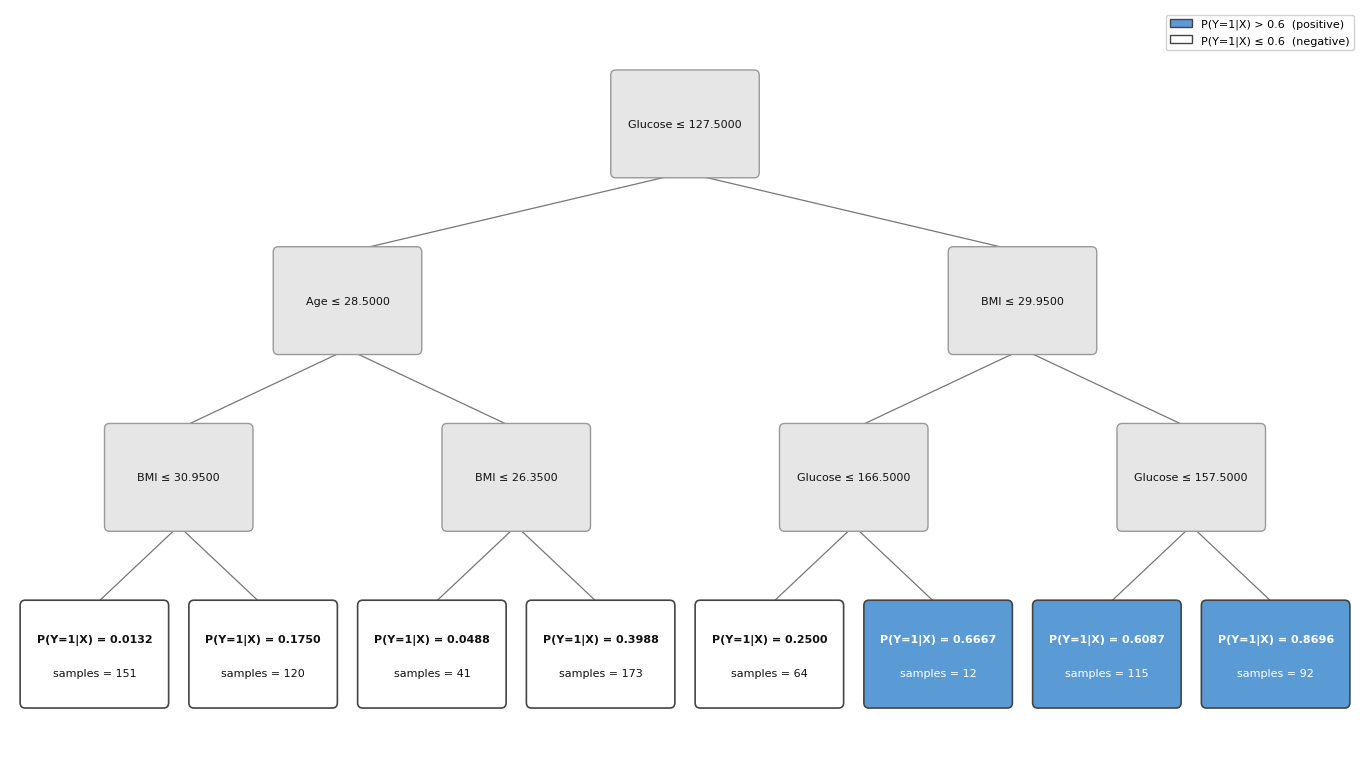

In [62]:
# pfs
model = CART(depth=max_depth, minimum_portion=0.02, lbd=0.5, cut=cut, method = 'pfs',feature_name = np.array(df_diabetes.columns))
model.fit(X1, y1)
model.print_tree()
plot_cart_tree(model.tree, feature_name=model.feature_name, cut=model.cut)

In [63]:
cut = 0.6
max_depth = 3

In [64]:
### kd rf ###        
rf = RandomForestClassifier(n_estimators = 100, random_state=6)
rf.fit(X1, y1)
phat = rf.predict_proba(X1)[:,1]

[Glucose <= 127.5000]
  [Age <= 28.5000]
    [BMI <= 30.9500]
      Leaf: mean=0.028, n=151
      Leaf: mean=0.186, n=120
    [BMI <= 26.9500]
      Leaf: mean=0.104, n=45
      Leaf: mean=0.396, n=169
  [BMI <= 29.9500]
    [Glucose <= 145.5000]
      Leaf: mean=0.193, n=41
      Leaf: mean=0.511, n=35
    [Glucose <= 157.5000]
      Leaf: mean=0.595, n=115
      Leaf: mean=0.830, n=92


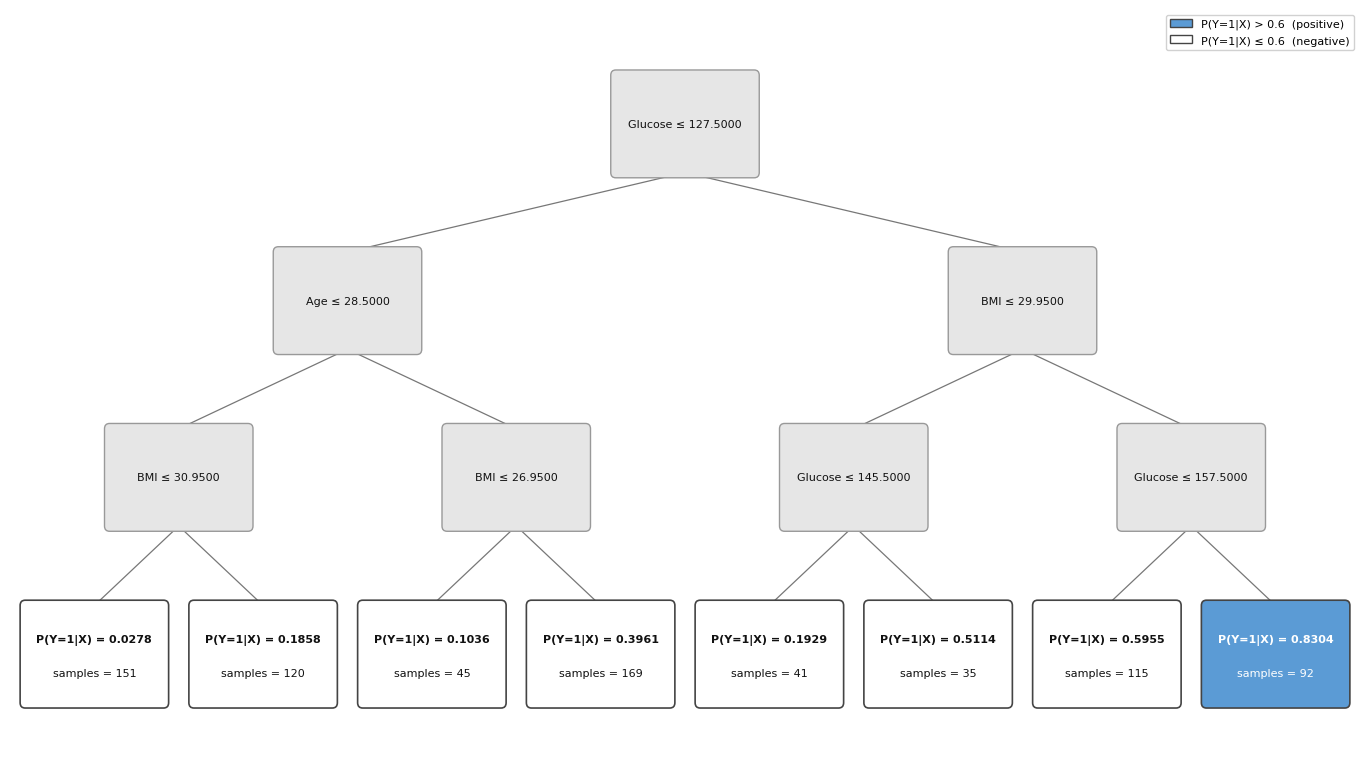

In [65]:
###### cart ######
model = CART(depth=max_depth, minimum_portion=0.03, cut=cut, method = 'cart',feature_name = np.array(df_diabetes.columns))
model.fit(X1, y1, phat)
model.print_tree()
plot_cart_tree(model.tree, feature_name=model.feature_name, cut=model.cut)

[Glucose <= 127.5000]
  [Age <= 28.5000]
    [BMI <= 22.2500]
      Leaf: mean=0.010, n=35
      Leaf: mean=0.111, n=236
    [BMI <= 28.2500]
      Leaf: mean=0.225, n=63
      Leaf: mean=0.380, n=151
  [BMI <= 29.9500]
    [Glucose <= 166.5000]
      Leaf: mean=0.284, n=64
      Leaf: mean=0.636, n=12
    [Glucose <= 129.5000]
      Leaf: mean=0.573, n=19
      Leaf: mean=0.713, n=188


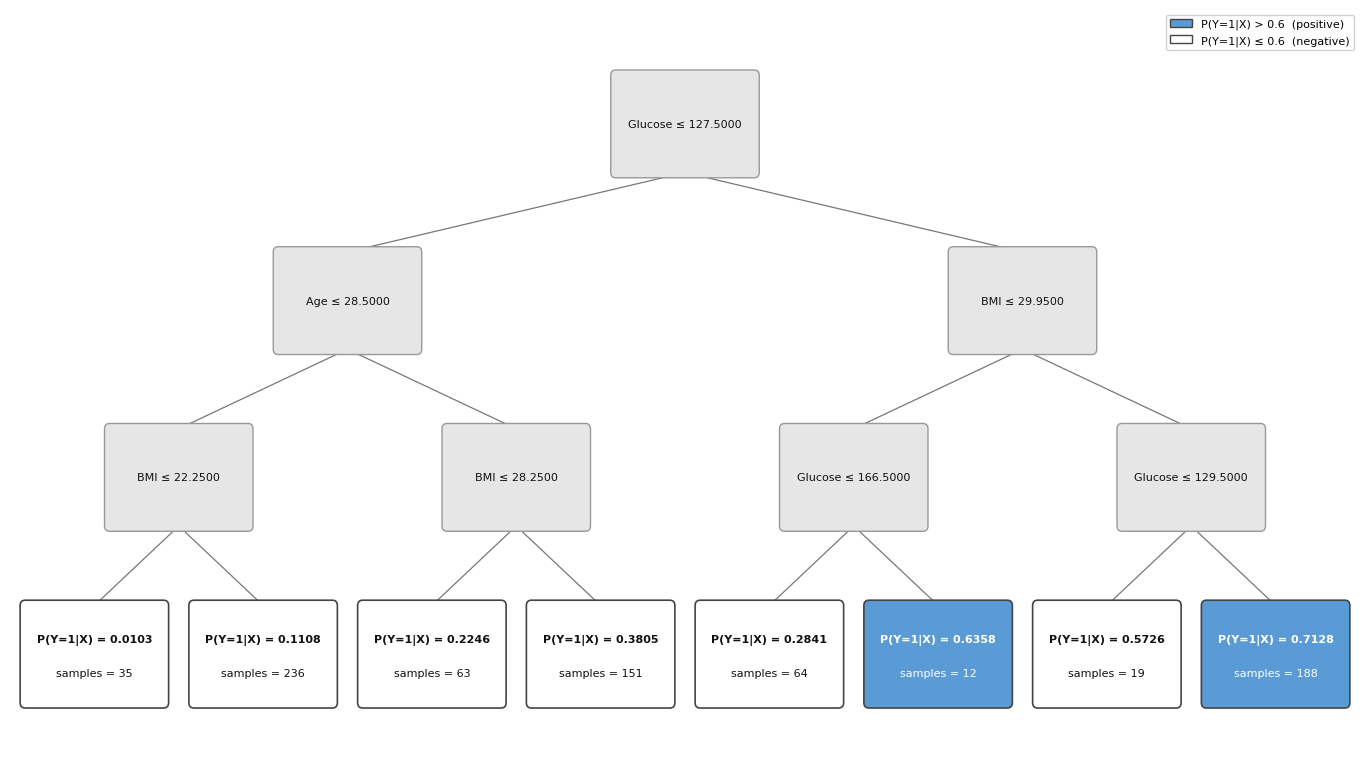

In [66]:
###### mdfs ######
model = CART(depth=max_depth, minimum_portion=0.03, lbd=1, cut=cut, method = 'mdfs',feature_name = np.array(df_diabetes.columns))
model.fit(X1, y1, phat)
model.print_tree()
plot_cart_tree(model.tree, feature_name=model.feature_name, cut=model.cut)

### 2. forestfires

In [67]:
df_forestfires = pd.read_csv(DATA_DIR / "forestfires.csv")
df_forestfires['month_num'] = df_forestfires['month'].map(
    {'jan': 1, 'feb':2, 'mar':3, 'apr':4, 'may':5, 'jun':6, 'jul':7, 'aug':8, 'sep':9,'oct':10,'nov':11,'dec':12})

In [68]:
y1 = np.array(1*(df_forestfires['area']>5))
X1 = np.array(df_forestfires.drop(['month', 'day','area','month_num'],axis=1))

In [69]:
df_forestfires_ = df_forestfires.drop(['month', 'day','area','month_num'],axis=1)

In [70]:
cut = 1/3
max_depth = 3

In [71]:
# df_forestfires_

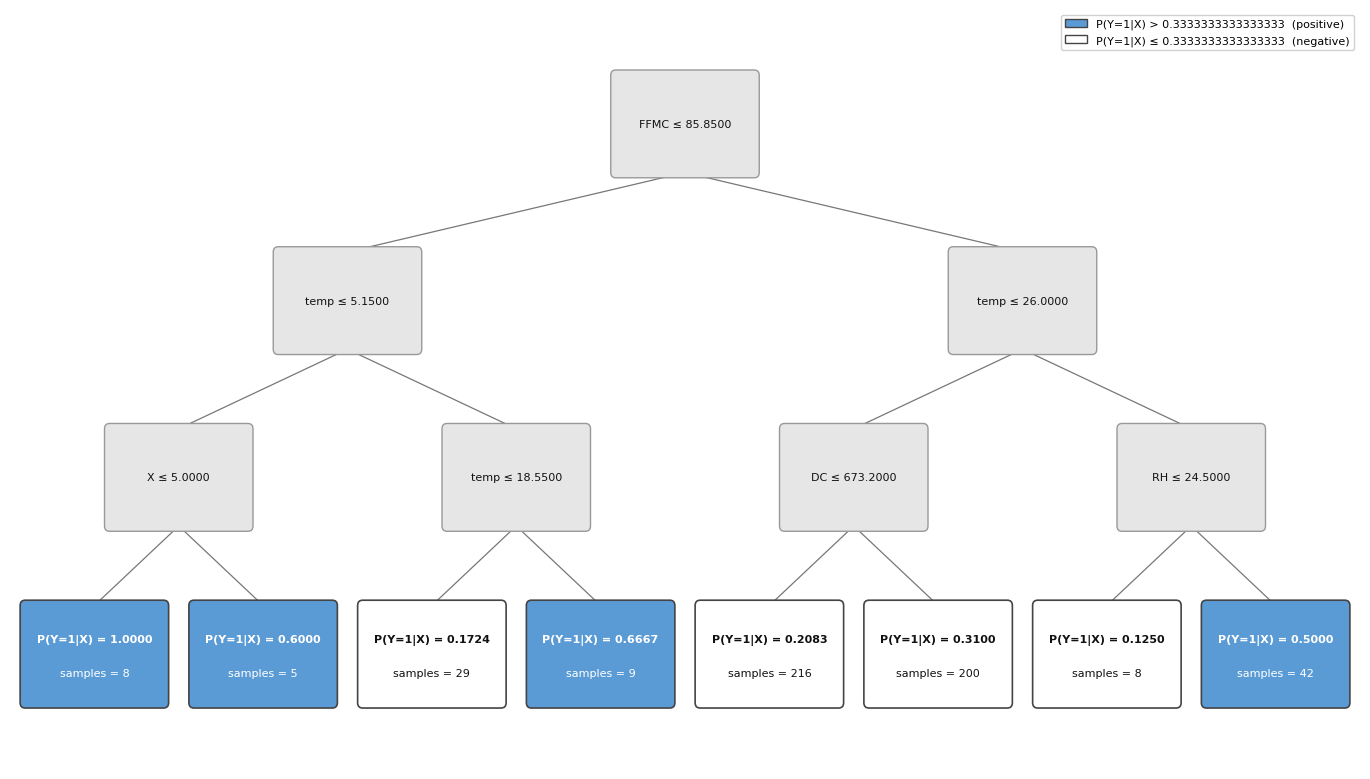

In [72]:
###### cart ######
model = CART(depth=max_depth, minimum_portion=0.02, cut=cut, method = 'cart',feature_name = np.array(df_forestfires_.columns))
model.fit(X1, y1)
plot_cart_tree(model.tree, feature_name=model.feature_name, cut=model.cut)


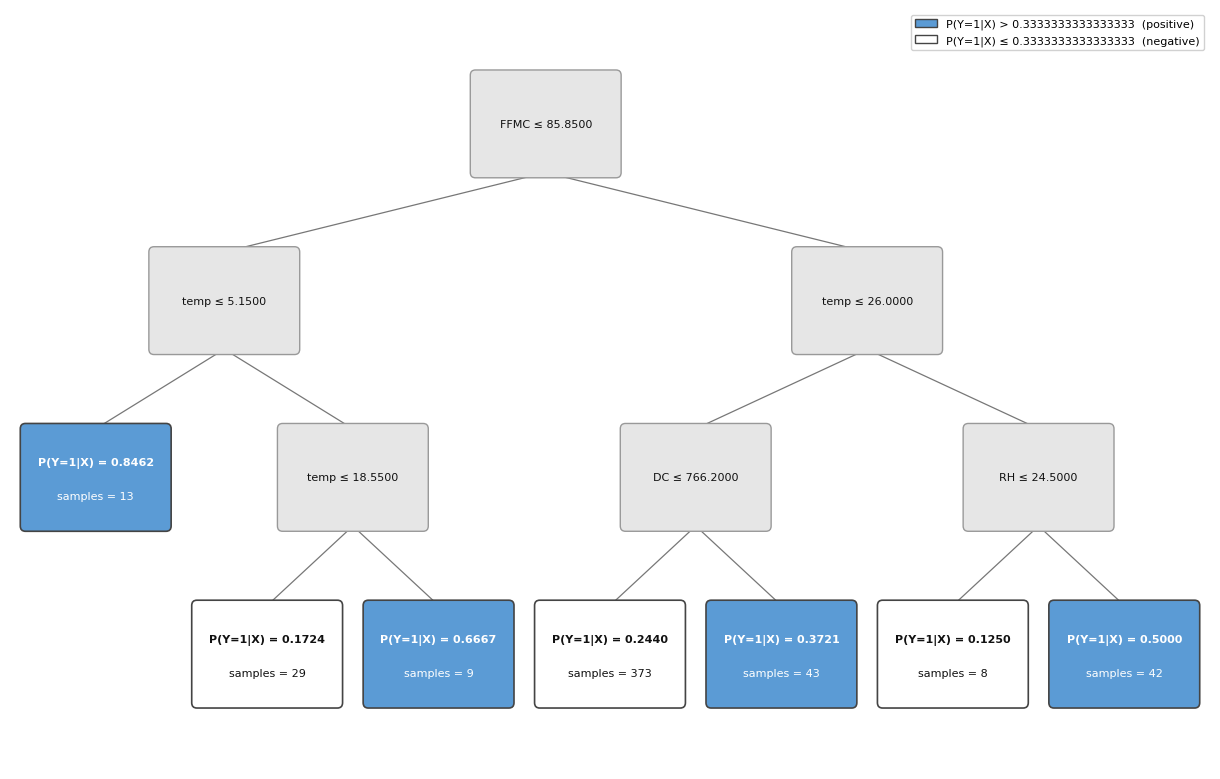

In [73]:
# mdfs
model = CART(depth=max_depth, minimum_portion=0.02, lbd=1, cut=cut, method = 'mdfs',feature_name = np.array(df_forestfires_.columns))
model.fit(X1, y1)
plot_cart_tree(model.tree, feature_name=model.feature_name, cut=model.cut)

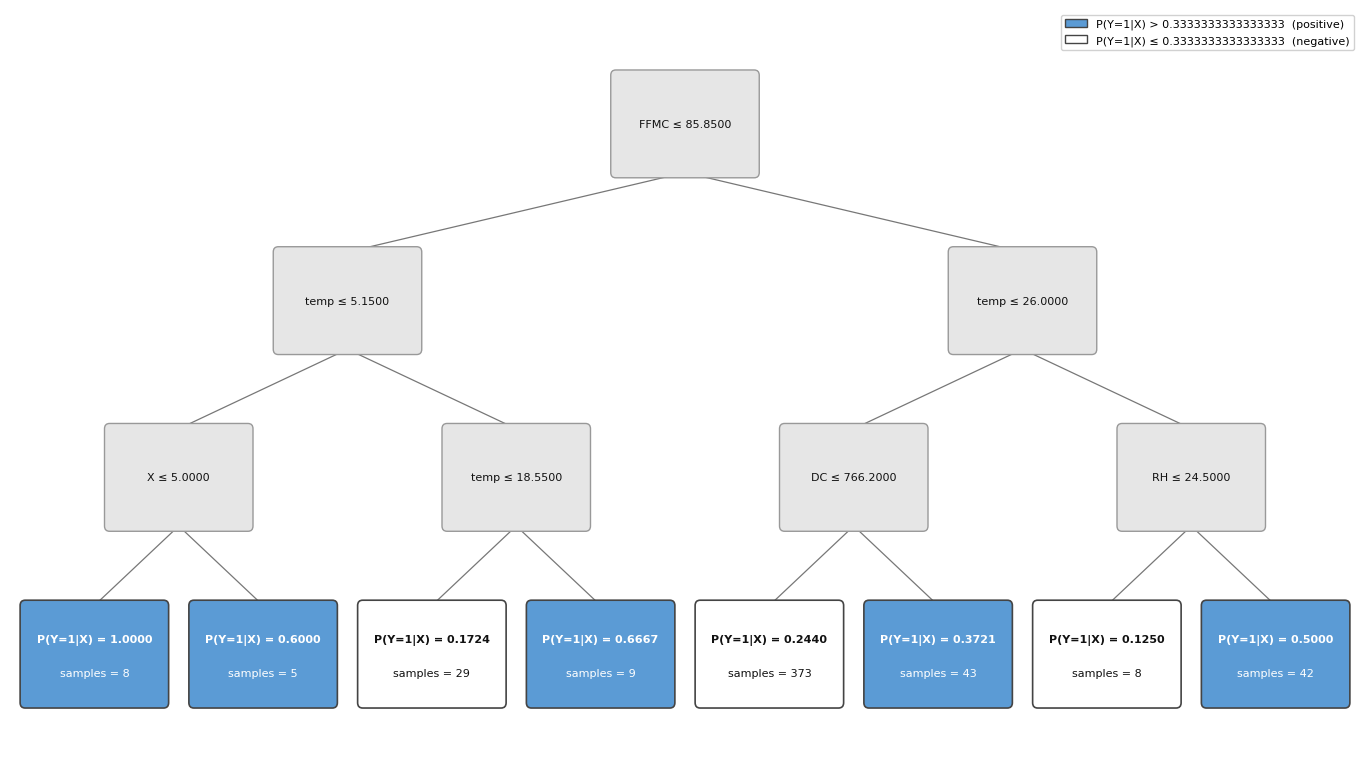

In [74]:
# pfs
model = CART(depth=max_depth, minimum_portion=0.02, lbd=0.5, cut=cut, method = 'pfs',feature_name = np.array(df_forestfires_.columns))
model.fit(X1, y1)
plot_cart_tree(model.tree, feature_name=model.feature_name, cut=model.cut)

In [75]:
cut = 1/3
max_depth = 3

In [76]:
### kd rf ###        
rf = RandomForestClassifier(n_estimators = 100, random_state=6)
rf.fit(X1, y1)
phat = rf.predict_proba(X1)[:,1]

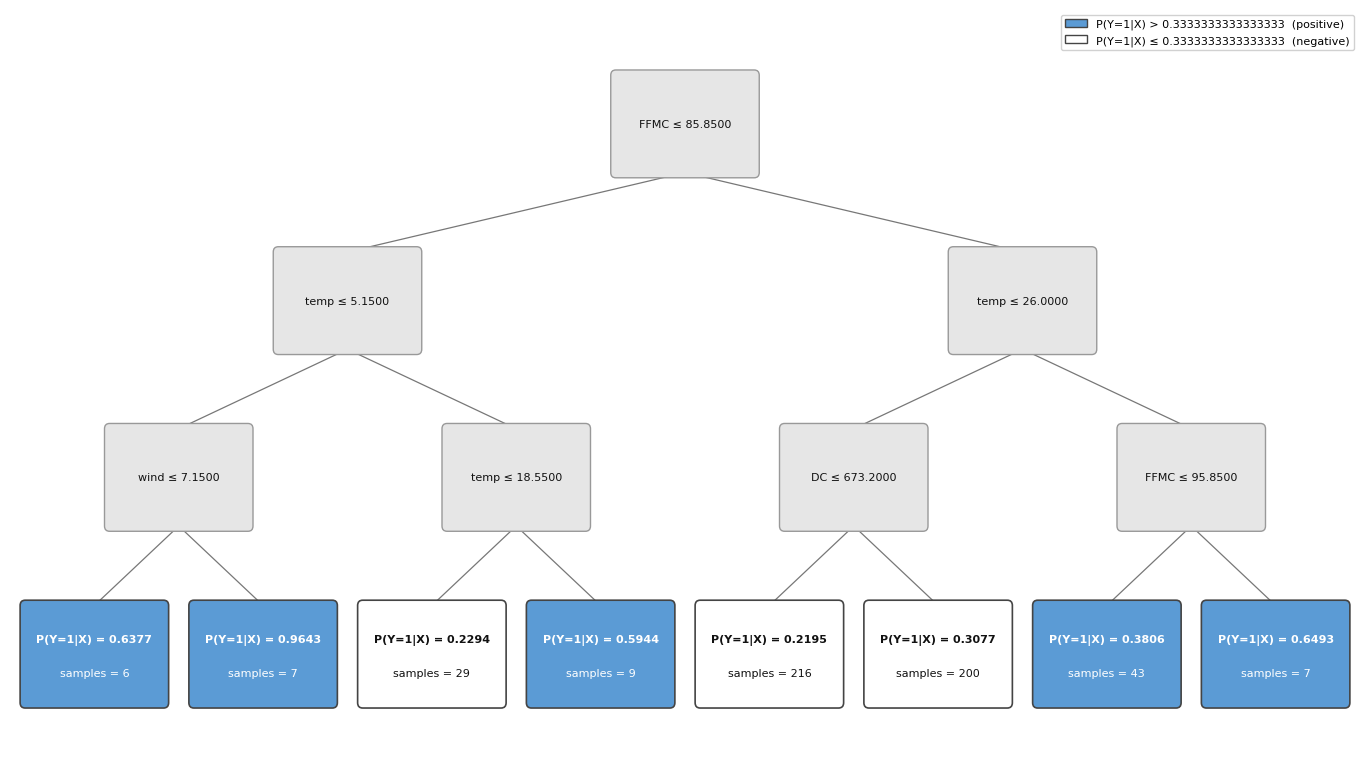

In [77]:
###### cart ######
model = CART(depth=max_depth, minimum_portion=0.02,cut=cut, method = 'cart',feature_name = np.array(df_forestfires_.columns))
model.fit(X1, y1, phat)
plot_cart_tree(model.tree, feature_name=model.feature_name, cut=model.cut)

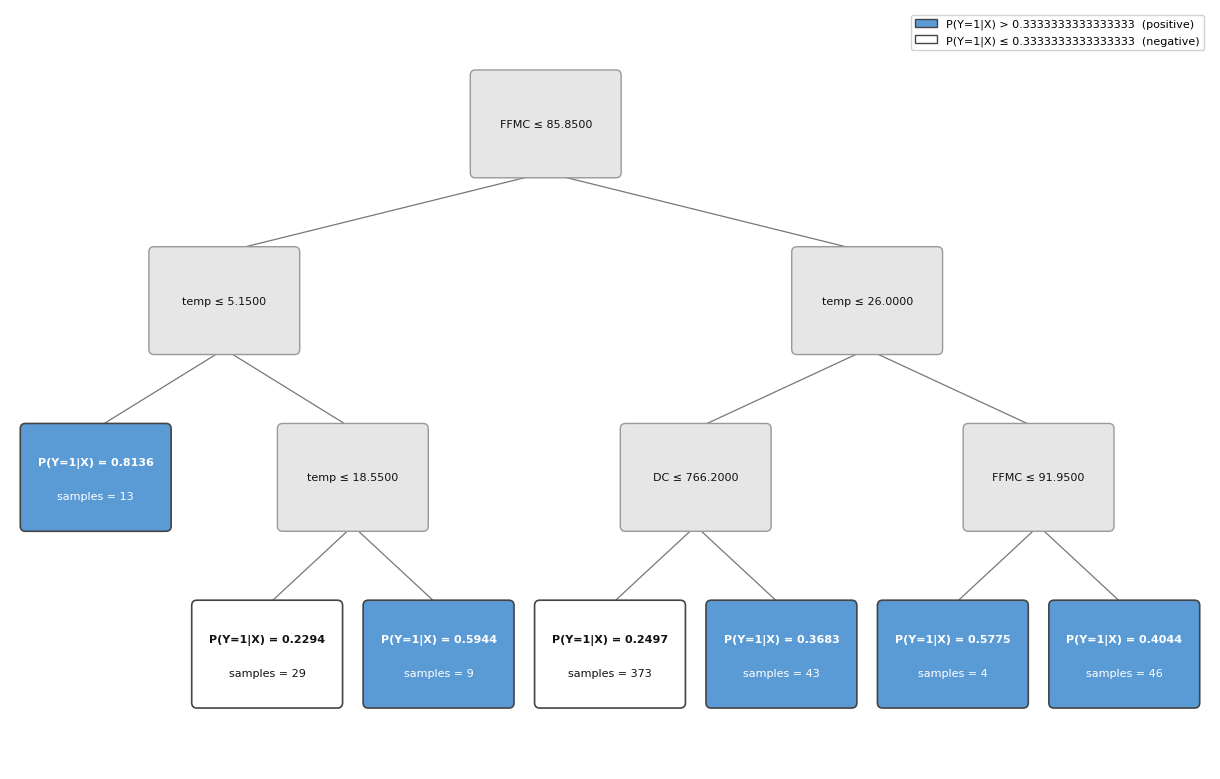

In [78]:
###### mdfs ######
model = CART(depth=max_depth, minimum_portion=0.02, lbd=1, cut=cut, method = 'mdfs',feature_name = np.array(df_forestfires_.columns))
model.fit(X1, y1, phat)
plot_cart_tree(model.tree, feature_name=model.feature_name, cut=model.cut)